Check path for data loading

In [2]:
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))  # ML-pipeline
search_root = os.path.join(project_root, "data")

print("Searching under:", search_root)

hits = []
for root, dirs, files in os.walk(search_root):
    if "features.txt" in files:
        hits.append(os.path.join(root, "features.txt"))

print("Found:", len(hits), "features.txt")
for h in hits:
    print(" -", h)

if not hits:
    raise FileNotFoundError("No features.txt found under ML-pipeline/data. Re-check extraction.")

Searching under: c:\Users\vPro\OneDrive - Al Akhawayn University in Ifrane\AUI\capstone\capstone\ML-pipeline\data
Found: 1 features.txt
 - c:\Users\vPro\OneDrive - Al Akhawayn University in Ifrane\AUI\capstone\capstone\ML-pipeline\data\raw\UCI HAR Dataset\UCI HAR Dataset\features.txt


1. Loading data and features

In [3]:
import os
import pandas as pd

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

base_dir = os.path.join(project_root, "data", "raw",
                        "UCI HAR Dataset", "UCI HAR Dataset")

print("base_dir =", base_dir)

X_train_path = os.path.join(base_dir, "train", "X_train.txt")
y_train_path = os.path.join(base_dir, "train", "y_train.txt")
X_test_path  = os.path.join(base_dir, "test",  "X_test.txt")
y_test_path  = os.path.join(base_dir, "test",  "y_test.txt")
features_path = os.path.join(base_dir, "features.txt")

# Load features
features = pd.read_csv(features_path, sep=r"\s+", header=None, names=["idx", "feature"])
feature_names = features["feature"].tolist()

# Load data
X_train = pd.read_csv(X_train_path, sep=r"\s+", header=None)
X_test  = pd.read_csv(X_test_path,  sep=r"\s+", header=None)

y_train = pd.read_csv(y_train_path, sep=r"\s+", header=None)[0]
y_test  = pd.read_csv(y_test_path,  sep=r"\s+", header=None)[0]

X_train.columns = feature_names
X_test.columns  = feature_names

print("Loaded successfully:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Labels :", sorted(y_train.unique()))

base_dir = c:\Users\vPro\OneDrive - Al Akhawayn University in Ifrane\AUI\capstone\capstone\ML-pipeline\data\raw\UCI HAR Dataset\UCI HAR Dataset
Loaded successfully:
X_train: (7352, 561)
X_test : (2947, 561)
Labels : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


1.1. Converting data to binary injury-risk classification

In [13]:
# Convert to binary injury-risk classification
# High risk: dynamic movements (1,2,3)
# Low risk: static postures (4,5,6)


y_train_binary = y_train.isin([1,2,3]).astype(int)
y_test_binary  = y_test.isin([1,2,3]).astype(int)

print("Binary labels distribution (train):")
print(y_train_binary.value_counts())

print("\nBinary labels distribution (test):")
print(y_test_binary.value_counts())

Binary labels distribution (train):
0
0    4067
1    3285
Name: count, dtype: int64

Binary labels distribution (test):
0
0    1560
1    1387
Name: count, dtype: int64


2. Train baseline models (Logistic Regression + Random Forest)

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression (scaling recommended)
logreg = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, n_jobs=None))  # n_jobs ignored in some versions
])

# Random Forest (scaling not required, but fine to keep X as-is)
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

logreg.fit(X_train, y_train)
rf.fit(X_train, y_train)

print("Trained Logistic Regression and Random Forest.")


Trained Logistic Regression and Random Forest.


2.1 Train Binary Classifier on baseline models ( LR & RF)

In [6]:
# Train Binary Classifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
logreg_bin = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

# Random Forest
rf_bin = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

logreg_bin.fit(X_train, y_train_binary)
rf_bin.fit(X_train, y_train_binary)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

3. Evaluate models (Confusion Matrix, F1, Recall)

In [7]:
# Step 5 — Evaluate (Confusion matrix, F1, Recall)
from sklearn.metrics import confusion_matrix, classification_report, f1_score, recall_score

def evaluate_model(model, X, y, name="model"):
    y_pred = model.predict(X)

    cm = confusion_matrix(y, y_pred)
    f1_macro = f1_score(y, y_pred, average="macro")
    recall_macro = recall_score(y, y_pred, average="macro")

    print(f"\n=== {name} ===")
    print("Confusion matrix:\n", cm)
    print(f"F1 (macro): {f1_macro:.4f}")
    print(f"Recall (macro): {recall_macro:.4f}")
    print("\nClassification report:\n", classification_report(y, y_pred, digits=4))

evaluate_model(logreg, X_test, y_test, "Logistic Regression")
evaluate_model(rf, X_test, y_test, "Random Forest")



=== Logistic Regression ===
Confusion matrix:
 [[493   0   3   0   0   0]
 [ 23 447   1   0   0   0]
 [  6  19 393   0   2   0]
 [  0   2   0 430  58   1]
 [  0   0   0  14 518   0]
 [  0   0   0   0   6 531]]
F1 (macro): 0.9540
Recall (macro): 0.9528

Classification report:
               precision    recall  f1-score   support

           1     0.9444    0.9940    0.9686       496
           2     0.9551    0.9490    0.9521       471
           3     0.9899    0.9357    0.9621       420
           4     0.9685    0.8758    0.9198       491
           5     0.8870    0.9737    0.9283       532
           6     0.9981    0.9888    0.9935       537

    accuracy                         0.9542      2947
   macro avg     0.9572    0.9528    0.9540      2947
weighted avg     0.9560    0.9542    0.9541      2947


=== Random Forest ===
Confusion matrix:
 [[484   6   6   0   0   0]
 [ 34 431   6   0   0   0]
 [ 20  40 360   0   0   0]
 [  0   0   0 435  56   0]
 [  0   0   0  42 490   0]
 [

3.1 Evaluate Binary Model

In [8]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score, recall_score

def eval_binary(model, name):
    pred = model.predict(X_test)
    print(f"\n=== {name} (Binary Injury Risk) ===")
    print("Confusion matrix:\n", confusion_matrix(y_test_binary, pred))
    print("F1:", round(f1_score(y_test_binary, pred), 4))
    print("Recall:", round(recall_score(y_test_binary, pred), 4))
    print("\nReport:\n", classification_report(y_test_binary, pred, digits=4))

eval_binary(logreg_bin, "Logistic Regression")
eval_binary(rf_bin, "Random Forest")


=== Logistic Regression (Binary Injury Risk) ===
Confusion matrix:
 [[1559    1]
 [   0 1387]]
F1: 0.9996
Recall: 1.0

Report:
               precision    recall  f1-score   support

           0     1.0000    0.9994    0.9997      1560
           1     0.9993    1.0000    0.9996      1387

    accuracy                         0.9997      2947
   macro avg     0.9996    0.9997    0.9997      2947
weighted avg     0.9997    0.9997    0.9997      2947


=== Random Forest (Binary Injury Risk) ===
Confusion matrix:
 [[1560    0]
 [   0 1387]]
F1: 1.0
Recall: 1.0

Report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1560
           1     1.0000    1.0000    1.0000      1387

    accuracy                         1.0000      2947
   macro avg     1.0000    1.0000    1.0000      2947
weighted avg     1.0000    1.0000    1.0000      2947



4. SVM baseline to train and evaluate binary injury-risk labels

In [9]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, f1_score, recall_score

# 1) Define the model (RBF kernel is a strong default baseline)
svm_bin = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

# 2) Train
svm_bin.fit(X_train, y_train_binary)

# 3) Evaluate
pred = svm_bin.predict(X_test)

print("\n=== SVM (RBF) (Binary Injury Risk) ===")
print("Confusion matrix:\n", confusion_matrix(y_test_binary, pred))
print("F1:", round(f1_score(y_test_binary, pred), 4))
print("Recall:", round(recall_score(y_test_binary, pred), 4))
print("\nReport:\n", classification_report(y_test_binary, pred, digits=4))


=== SVM (RBF) (Binary Injury Risk) ===
Confusion matrix:
 [[1559    1]
 [   0 1387]]
F1: 0.9996
Recall: 1.0

Report:
               precision    recall  f1-score   support

           0     1.0000    0.9994    0.9997      1560
           1     0.9993    1.0000    0.9996      1387

    accuracy                         0.9997      2947
   macro avg     0.9996    0.9997    0.9997      2947
weighted avg     0.9997    0.9997    0.9997      2947



N.B: The near-perfect performance indicates that activity-type-based risk labeling is linearly separable and does not represent realistic injury risk modeling complexity.

We need to create a more realistic risk definition based on motion intensity features instead of activity ID

In [10]:
import numpy as np

# Choose a few strong motion/instability features that exist in HAR
risk_features = [
    "tBodyAccMag-std()",
    "tBodyAccJerkMag-std()",
    "tBodyGyroMag-std()",
    "tBodyGyroJerkMag-std()",
]

# Verify they exist
missing = [f for f in risk_features if f not in X_train.columns]
if missing:
    raise ValueError(f"Missing features in dataset: {missing}")

# Build a continuous risk score (simple, interpretable)
risk_score_train = X_train[risk_features].mean(axis=1)
risk_score_test  = X_test[risk_features].mean(axis=1)

print("Risk score (train) min/mean/max:",
      float(risk_score_train.min()), float(risk_score_train.mean()), float(risk_score_train.max()))

Risk score (train) min/mean/max: -0.9993493899999999 -0.6637867723108162 0.796521145


In [11]:
# Define threshold on TRAIN only (important to avoid leakage)
threshold = risk_score_train.quantile(0.75)

y_train_risk = (risk_score_train >= threshold).astype(int)
y_test_risk  = (risk_score_test  >= threshold).astype(int)

print("Threshold:", float(threshold))
print("\nTrain label distribution:\n", y_train_risk.value_counts(normalize=True))
print("\nTest label distribution:\n", y_test_risk.value_counts(normalize=True))

Threshold: -0.3607550725

Train label distribution:
 0    0.75
1    0.25
Name: proportion, dtype: float64

Test label distribution:
 0    0.77265
1    0.22735
Name: proportion, dtype: float64


In [12]:
# Train using y_train_risk instead of y_train_binary
logreg_bin.fit(X_train, y_train_risk)
rf_bin.fit(X_train, y_train_risk)
svm_bin.fit(X_train, y_train_risk)

# Evaluate using y_test_risk
from sklearn.metrics import confusion_matrix, classification_report, f1_score, recall_score, precision_score

def eval_risk(model, name):
    pred = model.predict(X_test)
    print(f"\n=== {name} (Data-driven Risk) ===")
    print("Confusion matrix:\n", confusion_matrix(y_test_risk, pred))
    print("Precision (risk=1):", round(precision_score(y_test_risk, pred), 4))
    print("Recall (risk=1):   ", round(recall_score(y_test_risk, pred), 4))
    print("F1 (risk=1):       ", round(f1_score(y_test_risk, pred), 4))
    print("\nReport:\n", classification_report(y_test_risk, pred, digits=4))

eval_risk(logreg_bin, "Logistic Regression")
eval_risk(rf_bin, "Random Forest")
eval_risk(svm_bin, "SVM RBF")


=== Logistic Regression (Data-driven Risk) ===
Confusion matrix:
 [[2246   31]
 [  11  659]]
Precision (risk=1): 0.9551
Recall (risk=1):    0.9836
F1 (risk=1):        0.9691

Report:
               precision    recall  f1-score   support

           0     0.9951    0.9864    0.9907      2277
           1     0.9551    0.9836    0.9691       670

    accuracy                         0.9857      2947
   macro avg     0.9751    0.9850    0.9799      2947
weighted avg     0.9860    0.9857    0.9858      2947


=== Random Forest (Data-driven Risk) ===
Confusion matrix:
 [[2262   15]
 [  28  642]]
Precision (risk=1): 0.9772
Recall (risk=1):    0.9582
F1 (risk=1):        0.9676

Report:
               precision    recall  f1-score   support

           0     0.9878    0.9934    0.9906      2277
           1     0.9772    0.9582    0.9676       670

    accuracy                         0.9854      2947
   macro avg     0.9825    0.9758    0.9791      2947
weighted avg     0.9854    0.9854    

Cross-validation (stability check)

In [14]:
from sklearn.model_selection import cross_val_score

print("=== Cross-Validation (5-fold) ===")

for model, name in [
    (logreg_bin, "LogReg"),
    (rf_bin, "RandomForest"),
    (svm_bin, "SVM")
]:
    scores = cross_val_score(model, X_train, y_train_risk, cv=5, scoring="f1")
    print(f"{name} F1 mean: {scores.mean():.4f} | std: {scores.std():.4f}")

=== Cross-Validation (5-fold) ===
LogReg F1 mean: 0.9660 | std: 0.0064
RandomForest F1 mean: 0.9415 | std: 0.0091
SVM F1 mean: 0.9417 | std: 0.0061


ROC Curve and AUC

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_bin = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True))
])

svm_bin.fit(X_train, y_train_risk)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


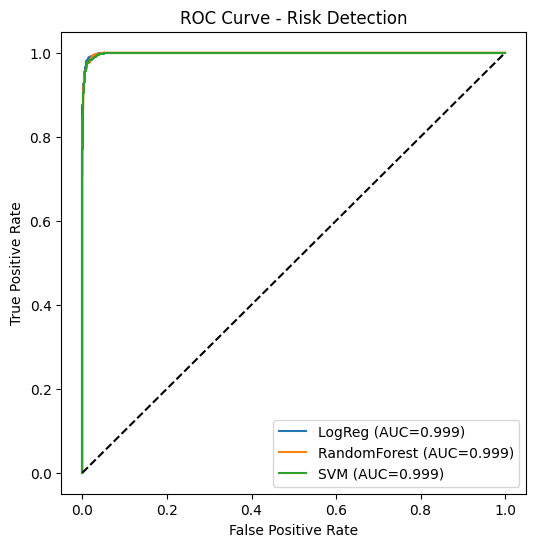

In [18]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

for model, name in [
    (logreg_bin, "LogReg"),
    (rf_bin, "RandomForest"),
    (svm_bin, "SVM")
]:
    model.fit(X_train, y_train_risk)
    probs = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test_risk, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Risk Detection")
plt.legend()
plt.show()